In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# 1.) Import Libraries

In [1]:
import os
import glob
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import cv2
from ultralytics import YOLO
import shutil
import yaml

# 2.) EDA

## 2.1) Data Visualization

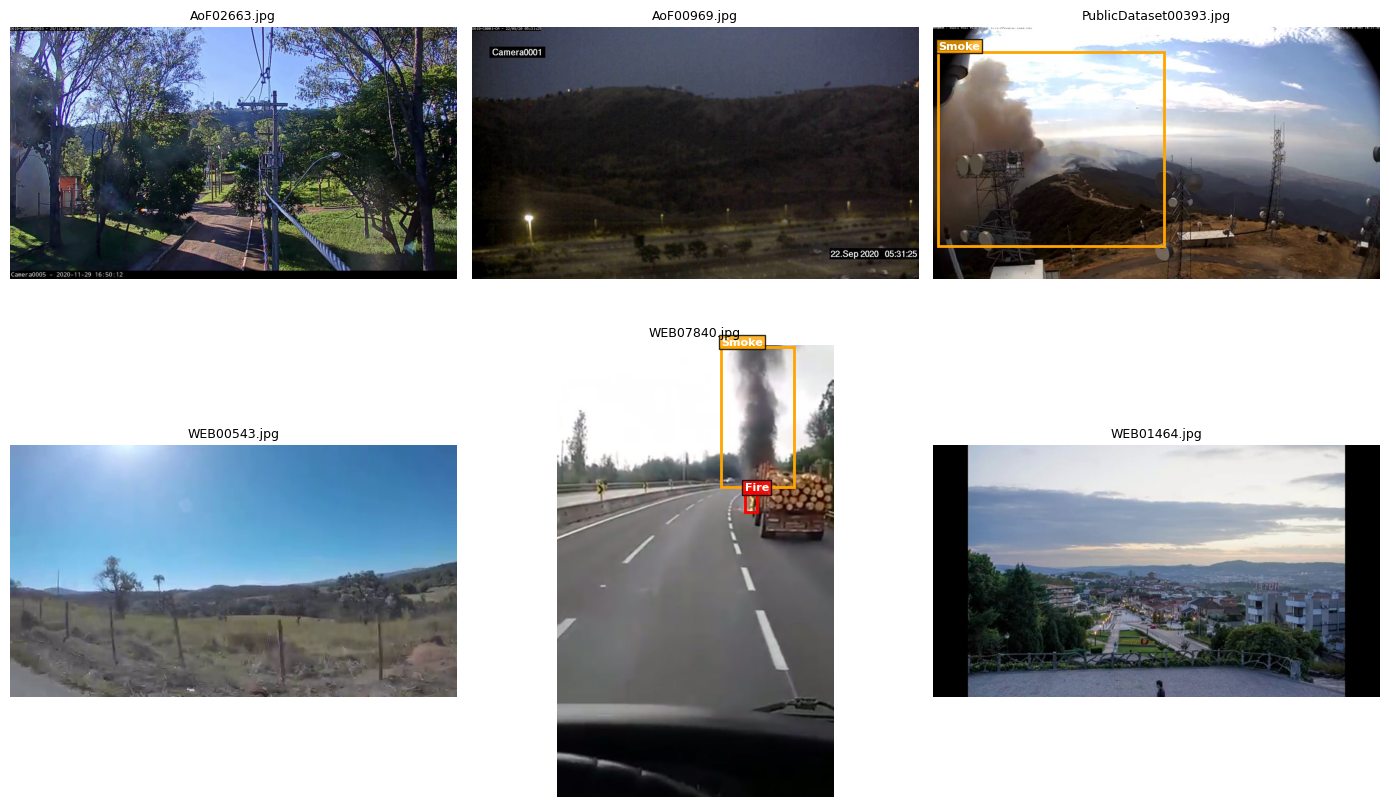

In [6]:
IMAGE_DIR = "/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/train/images"
LABEL_DIR = "/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/train/labels"

# Define class names (adjust mapping based on your data.yaml)
CLASS_NAMES = {0: "Smoke", 1: "Fire"}
COLORS = {0: "orange", 1: "red"}

image_paths = glob.glob(os.path.join(IMAGE_DIR, "*.[jJ][pP][gG]")) + \
              glob.glob(os.path.join(IMAGE_DIR, "*.[pP][nN][gG]"))

num_samples = min(6, len(image_paths))
sampled_paths = random.sample(image_paths, num_samples)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for idx, img_path in enumerate(sampled_paths):
    img = Image.open(img_path)
    img_w, img_h = img.size
    ax = axes[idx]
    ax.imshow(img)
    ax.set_title(os.path.basename(img_path), fontsize=9)
    ax.axis("off")

    # Locate matching label file
    base_name = os.path.splitext(os.path.basename(img_path))[0]
    label_path = os.path.join(LABEL_DIR, f"{base_name}.txt")

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            
            cls_id, x_c, y_c, w, h = map(float, parts)
            cls_id = int(cls_id)

            # Convert normalized YOLO coordinates (0-1) to pixel bounding box coordinates
            xmin = (x_c - w / 2) * img_w
            ymin = (y_c - h / 2) * img_h
            box_w = w * img_w
            box_h = h * img_h

            # Draw rectangle bounding box
            color = COLORS.get(cls_id, "cyan")
            rect = patches.Rectangle(
                (xmin, ymin), box_w, box_h, 
                linewidth=2, edgecolor=color, facecolor="none"
            )
            ax.add_patch(rect)

            # Add class label text above box
            label_text = CLASS_NAMES.get(cls_id, f"Class {cls_id}")
            ax.text(
                xmin, ymin - 4, label_text, 
                color="white", fontsize=8, weight="bold",
                bbox=dict(boxstyle="square,pad=0.2", facecolor=color, alpha=0.8)
            )

plt.tight_layout()
plt.show()

## 2.2) Data preprocessing

In [2]:
# Paths
SOURCE_BASE = '/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data'
DEST_BASE = '/kaggle/working/preprocessed_data'
SPLITS = ['train', 'val', 'test']

def apply_clahe_preprocessing(img_bgr):
    """Applies CLAHE to the L channel in LAB color space."""
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    
    enhanced_lab = cv2.merge((cl, a, b))
    enhanced_bgr = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)
    return enhanced_bgr

# Loop through train, val, and test splits
for split in SPLITS:
    src_img_dir = os.path.join(SOURCE_BASE, split, 'images')
    src_lbl_dir = os.path.join(SOURCE_BASE, split, 'labels')
    
    dst_img_dir = os.path.join(DEST_BASE, split, 'images')
    dst_lbl_dir = os.path.join(DEST_BASE, split, 'labels')
    
    os.makedirs(dst_img_dir, exist_ok=True)
    os.makedirs(dst_lbl_dir, exist_ok=True)
    
    if not os.path.exists(src_img_dir):
        continue
        
    print(f"Processing {split} set...")
    
    # 1. Preprocess and save images
    for img_name in os.listdir(src_img_dir):
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            src_path = os.path.join(src_img_dir, img_name)
            dst_path = os.path.join(dst_img_dir, img_name)
            
            img = cv2.imread(src_path)
            if img is not None:
                processed_img = apply_clahe_preprocessing(img)
                cv2.imwrite(dst_path, processed_img)

    # 2. Copy matching label .txt files directly
    if os.path.exists(src_lbl_dir):
        for lbl_name in os.listdir(src_lbl_dir):
            if lbl_name.endswith('.txt'):
                shutil.copy(
                    os.path.join(src_lbl_dir, lbl_name),
                    os.path.join(dst_lbl_dir, lbl_name)
                )

print("Preprocessing complete, Dataset saved to /kaggle/working/preprocessed_data")

Processing train set...
Processing val set...
Processing test set...
Preprocessing complete, Dataset saved to /kaggle/working/preprocessed_data


In [3]:
## Optimize data.yamal for our project and preprocessed data
preprocessed_yaml = {
    'path': '/kaggle/working/preprocessed_data',
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'names': {
        0: 'Smoke',
        1: 'Fire'
    }
}

with open('/kaggle/working/data_preprocessed.yaml', 'w') as f:
    yaml.dump(preprocessed_yaml, f)

print("Created data_preprocessed.yaml successfully!")

Created data_preprocessed.yaml successfully!


# 3.) YOLO11n Model

In [4]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 19.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 2.7 MB/s eta 0:00:00


In [5]:
# Load a pretrained YOLO model (nano or small variant)
model = YOLO('yolo11n.pt')

results = model.train(
    data='/kaggle/working/data_preprocessed.yaml',
    epochs=50,               
    imgsz=640,               # Input resolution (640x640)
    batch=16,                
    patience=10,
    device=0,                # GPU device (0 for Kaggle GPU)
    workers=4,
    project='smoke_fire_yolo_2',
    name='preprocessed_clahe_run_2',
    
    # Custom Augmentations for Fire/Smoke project
    hsv_h=0.015,             # Hue variance
    hsv_s=0.6,               # Saturation boost for glowing fire
    hsv_v=0.4,               # Brightness jitter for day/night
    scale=0.5,               # Multiscale training to detect distant smoke
    mosaic=1.0,              # Mosaic augmentation for small-feature context
    mixup=0.1,               # Mixup for blending smoke opacity
)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.138 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_preprocessed.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipu

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


       2/50      3.36G      1.777      2.036      1.593         19        640: 100% ━━━━━━━━━━━━ 883/883 5.3it/s 2:450.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 97/97 6.6it/s 14.8s0.2s
                   all       3099       3932      0.315      0.358      0.248      0.101

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50      3.37G      1.874      2.127      1.691         16        640: 100% ━━━━━━━━━━━━ 883/883 5.4it/s 2:420.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 97/97 6.5it/s 14.9s0.2s
                   all       3099       3932      0.282      0.334      0.212     0.0818

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/50      3.37G      1.889      2.117      1.711         16        640: 100% ━━━━━━━━━━━━ 883/883 5.5it/s 2:400.3ss
                 Class     Imag

In [8]:
print("\n Evaluating Best Model on Validation Set...")
metrics = model.val()

print(f" Final mAP50    : {metrics.box.map50:.4f}")
print(f" Final mAP50-95 : {metrics.box.map:.4f}")


 Evaluating Best Model on Validation Set...
Ultralytics 8.4.138 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3137.4±1200.4 MB/s, size: 243.3 KB)
val: Scanning /kaggle/working/preprocessed_data/val/labels.cache... 3099 images, 1375 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3099/3099 1.1Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 194/194 10.8it/s 18.0s.2ss
                   all       3099       3932      0.765      0.688      0.759      0.439
                 Smoke       1550       1756      0.813      0.749      0.819      0.508
                  Fire        879       2176      0.717      0.626        0.7      0.371
Speed: 0.6ms preprocess, 2.2ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-2
 Final mAP50    : 0.7593
 Final mAP50-95 : 0.4391


In [16]:
# Load the saved best model
best_model = YOLO('/kaggle/working/runs/detect/smoke_fire_yolo_2/preprocessed_clahe_run_2/weights/best.pt')

# Run evaluation on the unseen TEST split
test_metrics = best_model.val(
    data='/kaggle/working/data_preprocessed.yaml',
    split='test',  # Evaluates on the test split instead of val
    batch=16,
    imgsz=640,
    device=0
)

print(f"\n--- UNSEEN TEST METRICS ---")
print(f" Test mAP50    : {test_metrics.box.map50:.4f}")
print(f" Test mAP50-95 : {test_metrics.box.map:.4f}")

Ultralytics 8.4.138 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2294.5±857.6 MB/s, size: 273.2 KB)
val: Scanning /kaggle/working/preprocessed_data/test/labels... 4306 images, 2005 backgrounds, 4 corrupt: 100% ━━━━━━━━━━━━ 4306/4306 1.3Kit/s 3.3s0.0s
val: /kaggle/working/preprocessed_data/test/images/WEB10769.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0297]
val: /kaggle/working/preprocessed_data/test/images/WEB10775.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0156]
val: /kaggle/working/preprocessed_data/test/images/WEB11598.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0359]
val: /kaggle/working/preprocessed_data/test/images/WEB11600.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates

In [11]:
# Path to your existing run folder from the directory tree
run_dir = '/kaggle/working/runs/detect/smoke_fire_yolo_2/preprocessed_clahe_run_2'
output_zip = '/kaggle/working/smoke_fire_run_2_results'

if os.path.exists(run_dir):
    shutil.make_archive(output_zip, 'zip', run_dir)
    print(f" Run compressed successfully to: {output_zip}.zip")
else:
    print(f" Directory not found: {run_dir}")

✅ Run compressed successfully to: /kaggle/working/smoke_fire_run_2_results.zip


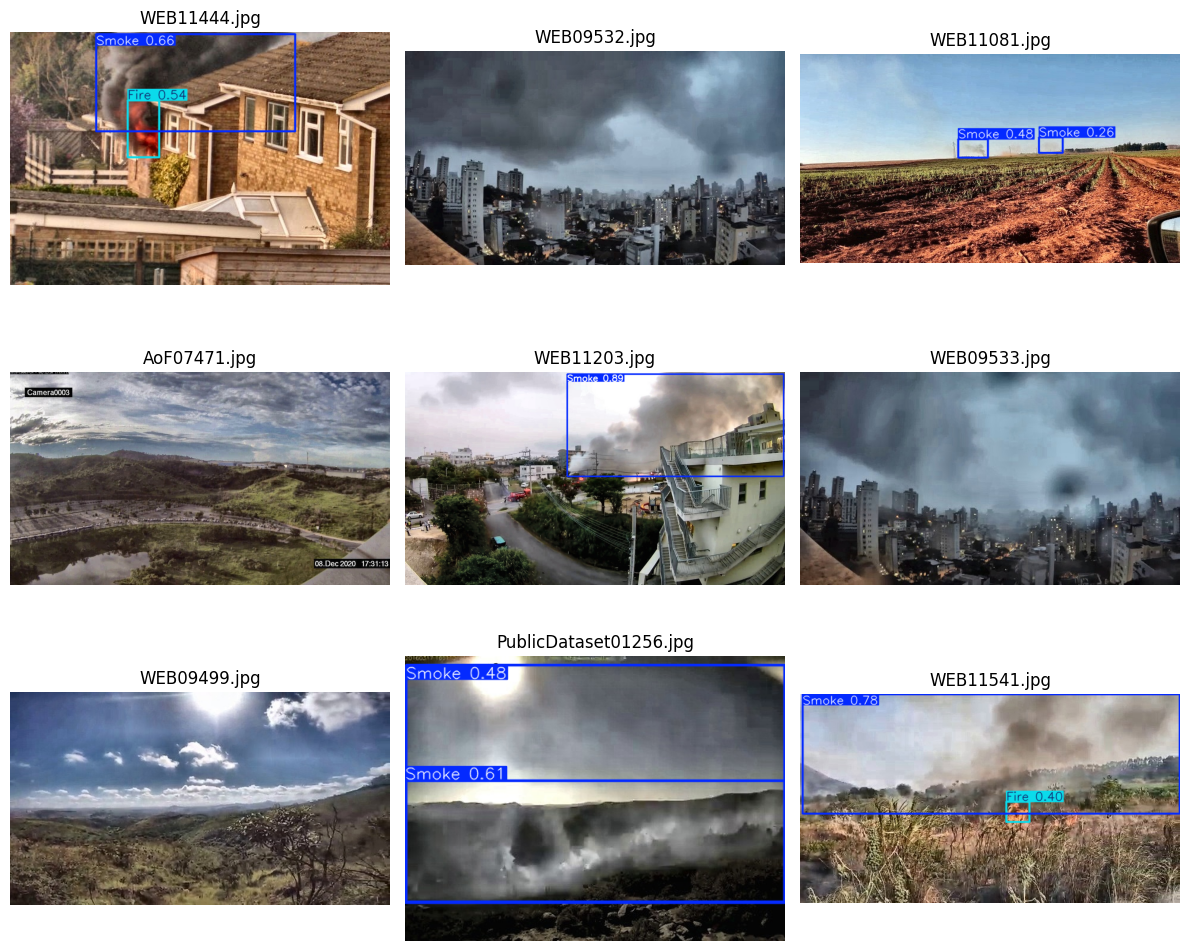

In [18]:
# 1. Path to your best trained model weights
# (If best.pt exists inside your run directory, use that; otherwise specify the model file)
model_path = '/kaggle/working/runs/detect/smoke_fire_yolo_2/preprocessed_clahe_run_2/weights/best.pt'

if not os.path.exists(model_path):
    # Fallback to pretrained model in working directory
    model_path = '/kaggle/working/yolo11n.pt' 

model = YOLO(model_path)

# 2. Get test images (Adjust search path to match your image folder)
test_images = glob('/kaggle/working/preprocessed_data/test/images/*.jpg')[:9]

# 3. Predict and display predictions
if test_images:
    fig, axes = plt.subplots(3, 3, figsize=(12, 10))
    axes = axes.ravel()

    for idx, img_path in enumerate(test_images):
        results = model.predict(source=img_path, conf=0.25, imgsz=640, verbose=False)
        
        # Draw bounding boxes (BGR -> RGB conversion)
        annotated_frame = results[0].plot()
        rgb_frame = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
        
        axes[idx].imshow(rgb_frame)
        axes[idx].set_title(os.path.basename(img_path))
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print(" No test images found. Check your test image directory path.")